<h1 align="center" style="color:blue;">
 Formation à la bibliothèque Matplotlib  : Data Visualistation
</h1>

<p align="center">
<b>Réalisé par :</b> SAKPANI Paguiyedou<br>
Étudiant en Licence Fondamentale  Sciences de l'Ingénieur<br>
Filière : Intelligence Artificielle & Big Data<br>
École Polytechnique de Lomé (EPL)
</p>

## Maîtrisez les bonnes pratiques de la data visualisation

#### En  résumé

- La datavisualisation est un ensemble de techniques utilisées pour représenter visuellement des informations clés sur un gros volume de données, afin d’en permettre la compréhension et l’analyse.

- #### Pour représenter :

   - une évolution dans le temps, on privilégiera des diagrammes en barres ou des courbes ;

   - une comparaison entre différents groupes, on utilisera un diagramme circulaire ou un diagrammes en barres ;

   - une distribution, on privilégiera un histogramme ou un diagramme à densité ;

   - a relation entre 2 variables numériques, on développera un nuage de points.

- Il existe quelques règles à observer pour réaliser un graphique efficace : 

    - privilégier la simplicité, quitte à multiplier le nombre de graphiques ;

    - privilégier la clarté, en proposant le plus d’informations possible pour permettre au lecteur d’interpréter seul ce graphique ;

    - choisir le graphique adéquat en fonction de ce qu’on cherche à représenter.

<h1 align ="center">Tracez des graphiques avec Matplotlib</h1>

Chaque représentation graphique a une fonction correspondante avec Matplotlib :

 - nuage de points ou scatter plot, en anglais :***scatter()*** ;

 - diagrammes en ligne ou en courbes :***plot()*** ;

 - diagrammes en barres :***bar()*** ;

 - histogrammes :***hist()*** ;

 - diagrammes circulaires :***pie()*** .

Que diriez-vous de découvrir une application concrète de ces fonctions ? C’est parti !

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Donnes_banques.csv") ## Importation de notre Dataset etudier dans la partie de la formation pandas sur openClassroom
def Risque(taux):
    if taux > 35 :
        return "OUI"
    else :
        return "NON"

data["risque"] = data.apply(
    lambda applique_ligne : Risque(applique_ligne["taux_endete"]), axis =1
)

data.to_csv("donnes_clients_avec_risque.csv", index = False)
data.head()

,identifiant,ville,CP,revenu,remboursement,duree,type,taux_interet,taux_endete,cout_total,benefices,risque
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80,271212.0,131.99,NON
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52,15360.0,23.69,NON
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50,374355.0,182.97,NON
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50,132609.6,53.71,NON
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80,105485.4,44.57,NON


##  Tracez vos premiers graphiques
<h4 style = "color : blue">Le nuage de points</h4>

Cherchons à représenter un des graphiques cités ci-dessus : représenter le taux d’endettement en fonction du revenu.
Ces deux variables sont numériques, sans évolution dans le temps : nous allons donc tracer un nuage de points, via la fonction scatter .
Cette fonction nécessite de définir x et y, qui sont les valeurs à placer en abscisse et en ordonnée :

Text(0, 0.5, "Taux d'endetement")

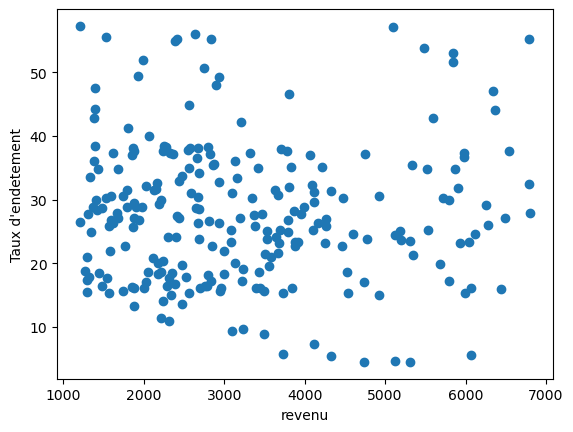

In [3]:
plt.figure()
plt.scatter(data["revenu"], data["taux_endete"])
plt.xlabel("revenu")
plt.ylabel("Taux d'endetement")

Il existe de nombreuses options pour personnaliser un nuage de points. On peut modifier :

   - la couleur des points, en utilisant l’argument **color** ou **c**;
    
   - la taille des points, via l’argument ***size*** ou ***s*** ;
    
   - le type de marqueur via l’argument ***marker** ;
    
   - la transparence des points via l’argument ***alpha*** .

Reprenons le même graphique, avec des croix rouges dont la taille aura été modifiée, et avec 50 % de transparence :

Text(0, 0.5, "Taux d'endetement")

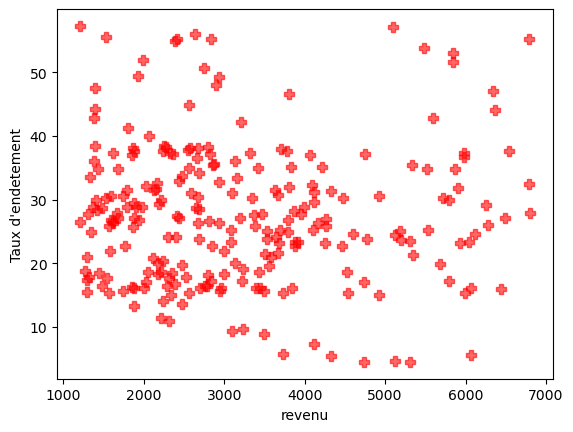

In [4]:
plt.figure()
plt.scatter(data["revenu"], data["taux_endete"], s = 60, alpha = 0.6, marker ="P" , c = "red")
plt.xlabel("revenu")
plt.ylabel("Taux d'endetement")

On souhaite maintenant représenter le chiffre d'affaires total par agence. Comme nous l’avons vu précédemment, il existe deux possibilités pour cela : 
soit ***un diagramme à barres, soit un diagramme circulaire***. Nous allons réaliser ces deux visualisations.

<h3 style = "color : blue">Le diagramme circulaire</h3>

Là où nous autres francophones et amateurs de fromages voyons dans le diagramme circulaire un camembert, les anglo-saxons y voient plutôt 
une tarte (pie, en anglais) à découper en plusieurs parts ! C’est de là que provient le nom de la fonction permettant de tracer un diagramme circulaire :pie .

- Son utilisation est très similaire à celle de **scatter** . Il y a deux arguments à préciser :***labels*** , correspondant à la variable non numérique, 
celle sur laquelle ont été agrégées les données, et ***x***, les valeurs agrégées correspondantes.

La première étape va donc être d’agréger les données :

In [5]:
df = data.groupby("ville")["remboursement"].sum()
dataset =df.reset_index()
dataset

,ville,remboursement
0,BORDEAUX,15330.59
1,LYON,26064.67
2,MARSEILLE,40895.72
3,NICE,23544.24
4,PARIS,94052.61
5,TOULOUSE,19286.18


([<matplotlib.patches.Wedge at 0x2d9c8ff1fd0>,
 [Text(1.0735482881610743, 0.23977921716951908, 'BORDEAUX'),
  Text(0.7559779757294925, 0.7990602606887286, 'LYON'),
  Text(-0.2207948127606491, 1.0776129410219561, 'MARSEILLE'),
  Text(-0.9928563382020422, 0.47353594551209344, 'NICE'),
  Text(-0.35667747630629365, -1.040567719034073, 'PARIS'),
  Text(1.058235353672122, -0.3002298057129555, 'TOULOUSE')])

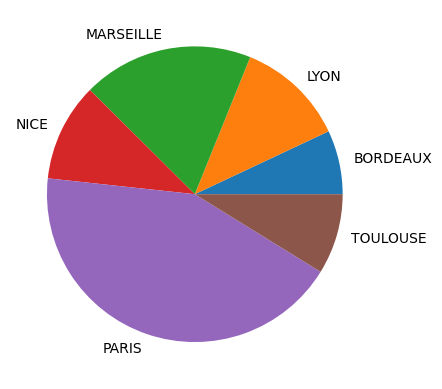

In [6]:
plt.pie(x = dataset["remboursement"], labels = dataset["ville"])

- On peut également améliorer ce graphique en affichant textuellement le pourcentage associé à chaque part.
Pour cela, il faut spécifier un format numérique via l’argument ***autopct** . Par exemple :

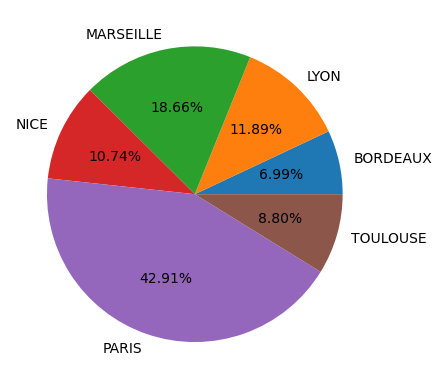

In [7]:
plt.pie(x = dataset["remboursement"], labels = dataset["ville"], autopct = "%.2f%%")
plt.show()

Explicitons rapidement ce format : il permet d’afficher la part du chiffre d'affaires total réalisé
par chaque agence, avec 2 chiffres après la virgule, et suivie du caractère% .



<h3 style = "color : blue">Le diagramme à barres</h3>
- L’alternative au diagramme circulaire est un diagramme à barres ! On peut représenter exactement la même information, mais avec une perspective différente.

Pour utiliser la fonctionbar , qui est l’implémentation de Matplotlib des diagrammes à barres, il faut préciser deux arguments :

    - x : les différentes valeurs de la variable non numérique, l’équivalent du **labels de pie** ;

    - height : les valeurs agrégées, équivalent du **x  de pie** .

- Représentons maintenant la même information – le chiffre d’affaires total par agence – via un diagramme à barres :

<BarContainer object of 6 artists>

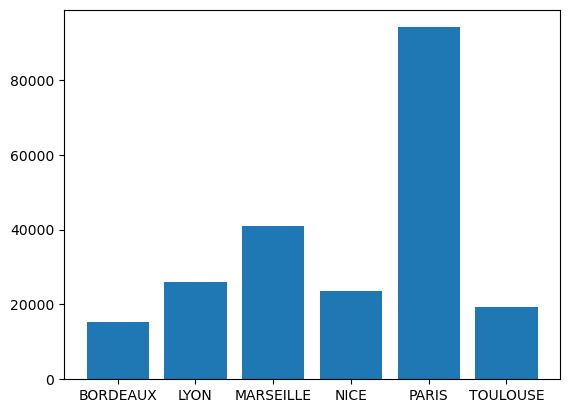

In [8]:
plt.bar( height =  dataset["remboursement"], x = dataset["ville"])

- Et si vous souhaitez ordonner du plus grand au plus petit ? Il faudra tricher un petit peu. En effet, 
la fonction **bar de Matplotlib** ne permet pas, par défaut, de réaliser cela… MAIS on peut tout de même trier le data frame en amont.

<BarContainer object of 244 artists>

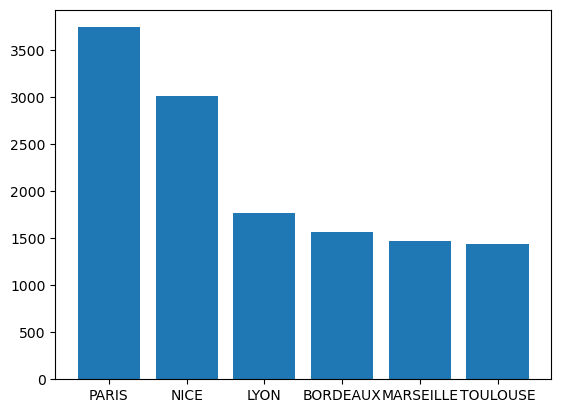

In [9]:
data_classer = data.sort_values("remboursement",ascending = False) #Trier les element dans l'ordre decroissant du chiffre d'affaire
plt.bar(height = data_classer["remboursement"], x = data_classer["ville"])


<h3 style = "color : blue">L 'histogramme</h3>

- Lorsqu’il s’agit de connaissance client dans le milieu bancaire, on arrive assez rapidement à la question : Comment se répartissent 
nos clients en termes de revenus ? A-t-on majoritairement des classes moyennes ? ou des revenus plus modestes ?

- L’histogramme est particulièrement utile lorsqu’on souhaite avoir une idée de la distribution d’une variable,
et donc particulièrement adéquat pour répondre à cette problématique. La fonction Matplotlib correspondante est ***hist*** .
Il suffit de lui passer en paramètre la variable numérique dont on souhaite connaître la distribution :

(array([21., 17., 21., 21., 21., 22., 15., 12., 16., 15., 11.,  6.,  5.,
         5.,  6.,  5.,  8.,  7.,  6.,  4.]),
 array([1200.  , 1480.35, 1760.7 , 2041.05, 2321.4 , 2601.75, 2882.1 ,
        3162.45, 3442.8 , 3723.15, 4003.5 , 4283.85, 4564.2 , 4844.55,
        5124.9 , 5405.25, 5685.6 , 5965.95, 6246.3 , 6526.65, 6807.  ]),
 <BarContainer object of 20 artists>)

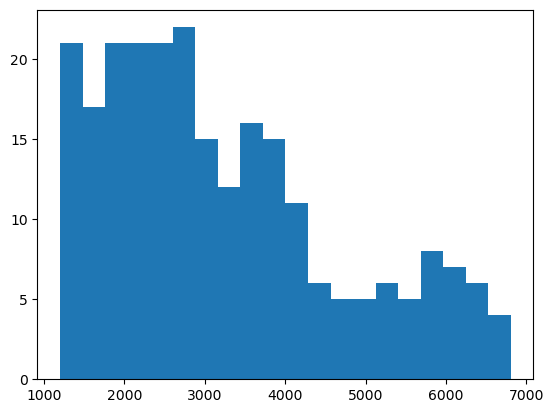

In [10]:
plt.hist(data["revenu"], bins = 20)


<h3 style = "color : blue">Les courbes</h3>                                      

On souhaite suivre l’évolution du chiffre d'affaires sur les 4 premiers mois, pour voir la façon dont il varie, et éventuellement anticiper la suite.

Nous avons pour cela à notre disposition le chiffre d'affaires réalisé par notre banque sur les prêts de janvier à avril 2013 :


In [11]:
evolution_ca = pd.DataFrame({
    "data" : ["2013-01-01", "2013-02-01", "2013-03-01","2013-04-01"],
    "chiffre d'affaire": [183000, 193020,179032, 219174]
})
evolution_ca

,data,chiffre d'affaire
0,2013-01-01,183000
1,2013-02-01,193020
2,2013-03-01,179032
3,2013-04-01,219174


On a ici une évolution dans le temps, donc le choix de représentation le plus pertinent serait de tracer une courbe.

Pour ce faire, on utilise la fonction ***plot*** de Matplotlib. Celle-ci prend deux arguments en entrée :
les informations à mettre en abscisse, et celles à mettre en ordonnée. Voilà comment tracer l’évolution de notre chiffre d’affaires :

Text(0, 0.5, "Chiffre d'affaires")

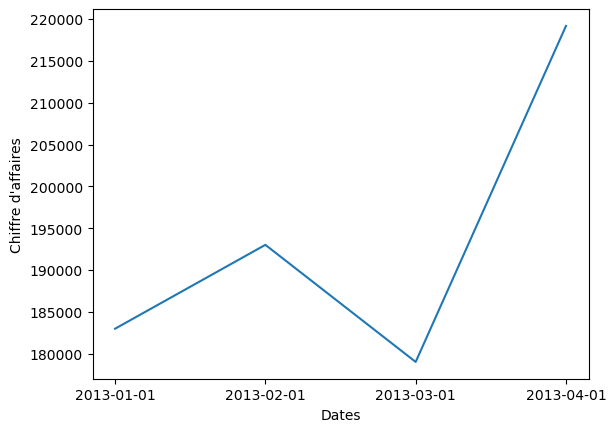

In [12]:
plt.plot(evolution_ca["data"], evolution_ca["chiffre d'affaire"])
plt.xlabel("Dates")
plt.ylabel("Chiffre d'affaires")

Comme pour le nuage de points, il existe de très nombreuses options de personnalisation. Vous pouvez jouer sur la couleur
de la ligne (  ***color  ou  c***  ), ***son style (  linestyle  ou  ls  )***, ***son épaisseur (  linewidth  ou  lw)***, si on souhaite ajouter 
un marqueur en plus de la ligne ***(  marker  )***, etc.

Text(0, 0.5, "Chiffre d'affaires")

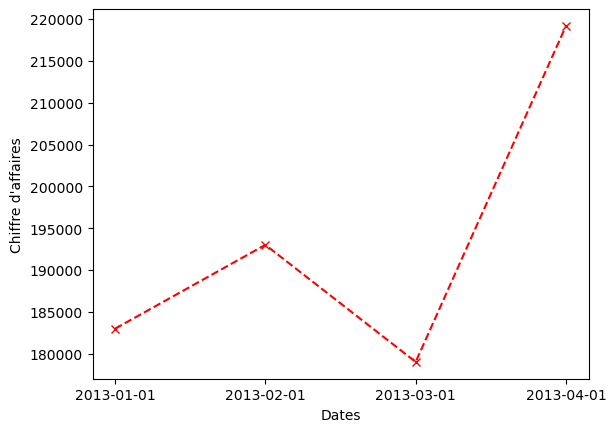

In [13]:
plt.plot(evolution_ca["data"], evolution_ca["chiffre d'affaire"], marker = "x", linestyle = "--", color = "red")
plt.xlabel("Dates")
plt.ylabel("Chiffre d'affaires")

Ces différents graphiques sont sympas, mais ils ne respectent pas vraiment les bonnes pratiques présentées précédemment...

- C’est un excellent point ! En effet, il manque pas mal d’informations sur l’ensemble de ces graphiques… mais ne vous inquiétez
pas, ce n’est pas un oubli de ma part, nous aurons l’occasion de voir comment corriger tout cela dans le prochain chapitre.

##                                               Créez plusieurs graphiques sur une même fenêtre

Nous avons 6 agences différentes avec plusieurs dizaines de clients par agence. Le responsable national souhaite avoir, en un seul graphique, une idée du comportement des agences en termes d’attribution de taux, en fonction du revenu.

Représenter le revenu en fonction du taux est assez simple : on peut faire cela via un nuage de points. Mais comment représenter, en plus, l’information de l’agence ? 

En ajoutant une information supplémentaire à notre graphique, comme la couleur des points !

Cependant, il n’existe pas d’option par défaut avec Matplotlib pour mettre en couleur les points. On va être forcés de créer plusieurs graphiques – un par agence – qu’on va superposer sur une seule et même fenêtre graphique.

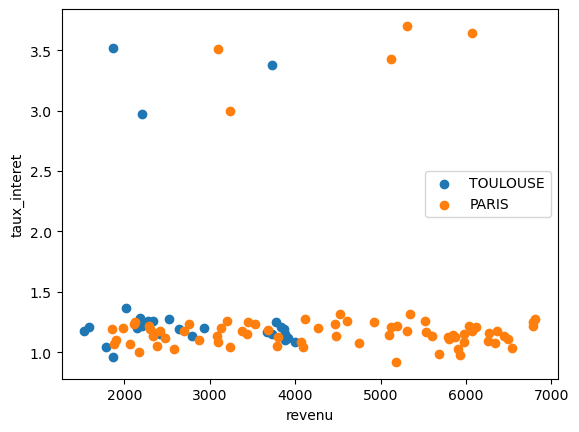

In [14]:
df1 = data.loc[data["ville"] == "TOULOUSE" ,:]
df2 = data.loc[data["ville"] == "PARIS", :]

plt.scatter(df1["revenu"], df1["taux_interet"], label = "TOULOUSE")
plt.scatter(df2["revenu"], df2["taux_interet"] , label = "PARIS")
plt.xlabel("revenu")
plt.ylabel("taux_interet")
plt.legend()

Text(0, 0.5, 'tax_interet')

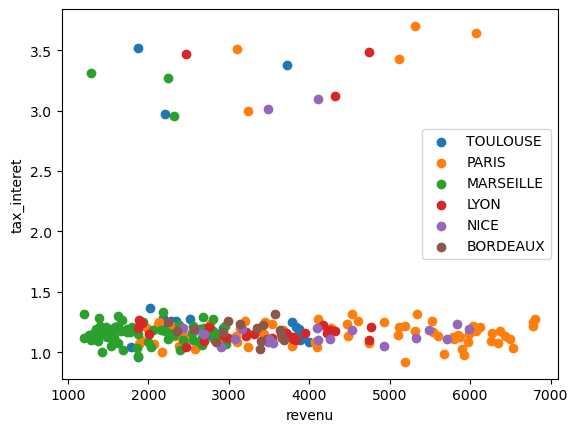

In [15]:
for agence in data["ville"].unique():
    df= data.loc[data["ville"] == agence, : ]
    plt.scatter(df["revenu"], df["taux_interet"], label = agence)
    plt.legend()
plt.xlabel("revenu")
plt.ylabel("tax_interet")

## Probleme

### Contexte

Vous êtes en train de préparer le reporting mensuel à présenter chaque fin de mois à votre responsable. La présentation devra comprendre certains graphiques clés : vous allez donc devoir utiliser vos compétences en data visualisation pour produire les différentes visualisations attendues.
Consignes

Les graphiques à produire sont donc :

   - la proportion de chaque type de prêt ;

   - le bénéfice mensuel réalisé en fonction du revenu du client pour les prêts immobiliers ;

   - la distribution des bénéfices réalisés ;

   - le bénéfice mensuel total réalisé par agence.

Je vous invite à vous entraîner en vous rendant sur l’exercice.

In [16]:
data.head()

,identifiant,ville,CP,revenu,remboursement,duree,type,taux_interet,taux_endete,cout_total,benefices,risque
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80,271212.0,131.99,NON
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52,15360.0,23.69,NON
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50,374355.0,182.97,NON
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50,132609.6,53.71,NON
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80,105485.4,44.57,NON


 #### 1-) La proportion de chaque type de pret

In [23]:
#pour ce data on a deux type de prets
df = data.groupby("type").size()
df = df.reset_index()
df =df.rename({0 : "nombre_clients" },axis = 1)
df

,type,nombre_clients
0,automobile,16
1,immobilier,228


([<matplotlib.patches.Wedge at 0x2d9cb24ee90>,
 [Text(1.076741255997668, 0.2250072612885306, 'automobile'),
  Text(-1.0767411860338134, -0.22500759609065896, 'immobilier')],
 [Text(0.5873134123623642, 0.12273123343010758, '6.56%'),
  Text(-0.5873133742002618, -0.12273141604945033, '93.44%')])

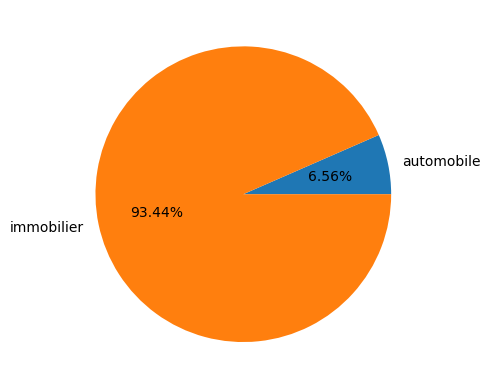

In [24]:
plt.pie(x= df["nombre_clients"], labels = df["type"], autopct = "%.2f%%")

<BarContainer object of 2 artists>

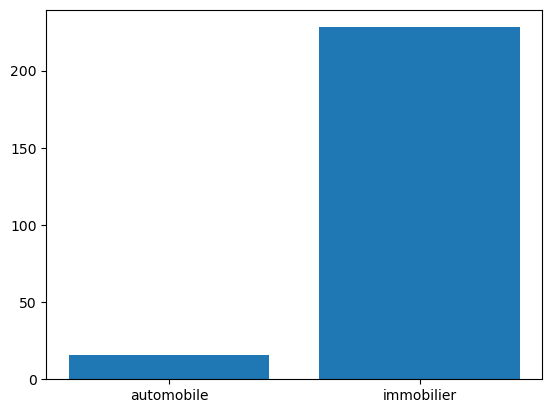

In [25]:
# Le diagramme de bar 

diag = df
plt.bar(x = diag["type"], height = diag["nombre_clients"])

#### 2-) le bénéfice mensuel réalisé en fonction du revenu du client pour les prêts immobiliers 

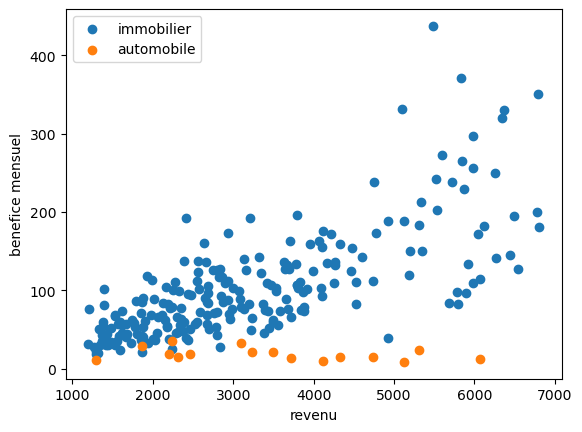

In [26]:
for i in data["type"].unique():
    df = data.loc[data["type"] == i, :]
    plt.scatter(df["revenu"], df["benefices"], label  = i)
    plt.legend()

plt.xlabel("revenu")
plt.ylabel("benefice mensuel")
plt.show()

#### 3- ) la distribution des bénéfices réalisés 

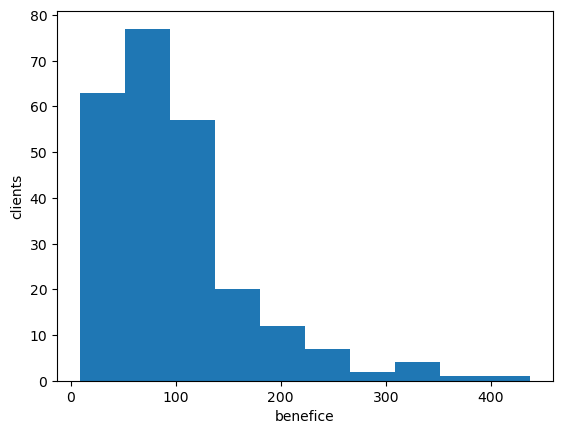

In [27]:
plt.hist(data["benefices"])
plt.xlabel("benefice")
plt.ylabel("clients")
plt.show()

#### 4 -) le bénéfice mensuel total réalisé par agence.

<BarContainer object of 6 artists>

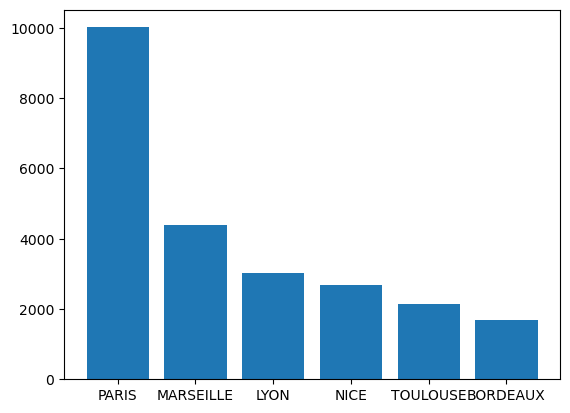

In [28]:
df = data.groupby("ville")["benefices"].sum()
df = df.reset_index()
df_Trier = df.sort_values("benefices", ascending = False)
plt.bar(x = df_Trier["ville"], height =  df_Trier["benefices"]) 